# Árvores de decisão

Francisco Aparecido Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>

<hr>

## Classificação

Vamos inicialmente ler os dados:

In [592]:
#from google.colab import drive
import pandas as pd
import numpy as np

# Mount Google Drive
#drive.mount('/content/drive')

# Load the Vehicle dataset. Assuming the file is located at '/content/drive/MyDrive/data/Vehicle.csv'
# If your file is in a different location, please adjust the path accordingly.
data = pd.read_csv('./data/Vehicle.csv', header=(0))

# remove NaN
data = data.dropna(axis='rows') #
# armazena o nome das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)  #name of the clases
features_names = data.columns

print("Número de linhas e colunas na matriz de atributos:", data.shape)
attributes = list(data.columns[0:-2])
# mostra os dados
data.head(10)

Número de linhas e colunas na matriz de atributos: (846, 19)


,Comp,Circ,D.Circ,Rad.Ra,Pr.Axis.Ra,Max.L.Ra,Scat.Ra,Elong,Pr.Axis.Rect,Max.L.Rect,Sc.Var.Maxis,Sc.Var.maxis,Ra.Gyr,Skew.Maxis,Skew.maxis,Kurt.maxis,Kurt.Maxis,Holl.Ra,Class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus
5,107,57,106,172,50,6,255,26,28,169,280,957,264,85,5,9,181,183,bus
6,97,43,73,173,65,6,153,42,19,143,176,361,172,66,13,1,200,204,bus
7,90,43,66,157,65,9,137,48,18,146,162,281,164,67,3,3,193,202,van
8,86,34,62,140,61,7,122,54,17,127,141,223,112,64,2,14,200,208,van
9,93,44,98,197,62,11,183,36,22,146,202,505,152,64,4,14,195,204,saab


Construímos as variáveis $X$ e $y$, sendo que o processo classificação se resume em estimar a função $f$ na relação $y = f(X) + \epsilon$, onde $\epsilon$ é o erro, que tem distribuição normal com média igual a zero e variância $\sigma^2$.

Convertemos para o formato Numpy pra facilitar a manipulação dos dados.

In [593]:
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

Para treinar o classificador, precisamos definir o conjunto de teste e treinamento.

In [594]:
from sklearn.model_selection import train_test_split
p = 0.2 # fracao de elementos no conjunto de teste
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = p, random_state = 42)

A partir desse conjunto de dados, podemos realizar a classificação.

Árvores de decisão podem ser construidas de diferentes formas, considerando diferentes métodos e medidas, como vimos na aula. Vamos incialmente construir a árvore usando o critério Gini:

In [595]:
from sklearn import tree
# Cria o modelo usando o criterio Gini
model = tree.DecisionTreeClassifier(criterion = 'gini', random_state = 101, max_depth = 2)
# Ajusta o modelo usando os dados de treinamento
model.fit(x_train,y_train)
# realizar a predição
y_pred = model.predict(x_test)

Usando a medida de acurácia, avaliamos o desempenho do modelo no aprendizado.

In [596]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
print('Accuracy:', score)

Accuracy: 0.5588235294117647


Podemos visualizar a árvore.

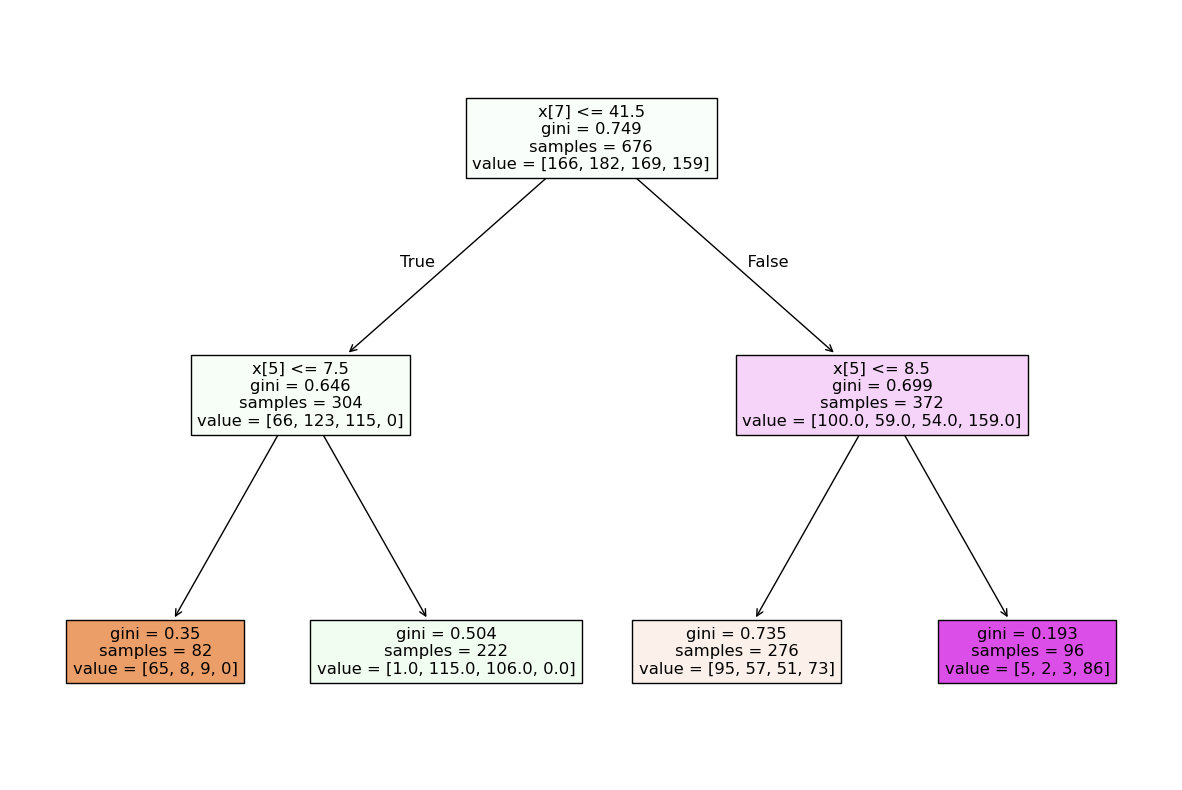

In [597]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
tree.plot_tree(model.fit(x_train,y_train),filled=True)
plt.show(True)

Se usarmos a medida de entropia:

In [598]:
from sklearn import tree
from sklearn.metrics import accuracy_score

model = tree.DecisionTreeClassifier(criterion = 'entropy',random_state = 101)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

score = accuracy_score(y_pred, y_test)
print('Accuracy:', score)

Accuracy: 0.7823529411764706


Mostrando a respectiva árvore.

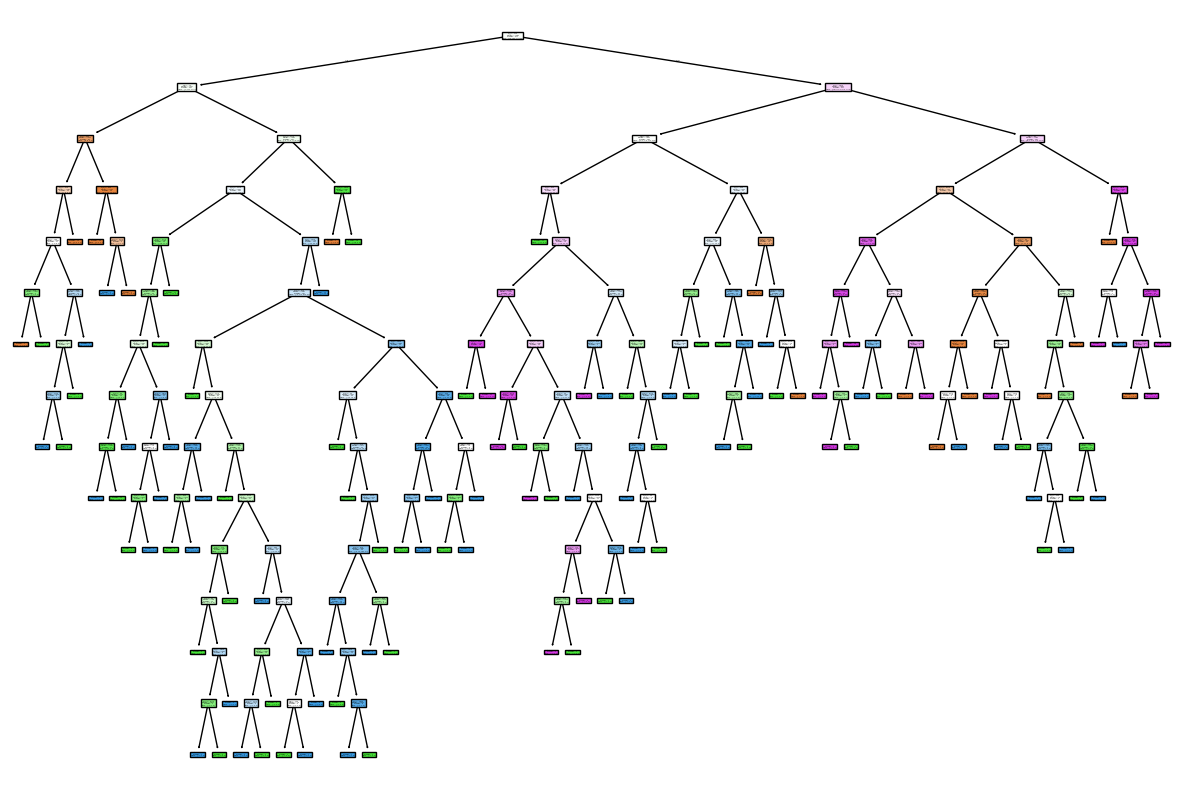

In [599]:
plt.figure(figsize=(15,10))
tree.plot_tree(model.fit(x_train,y_train), filled=True)
plt.show(True)

Podemos também limitar o tamanho da árvore, o que influencia no resultado:

In [600]:
from sklearn import tree
from sklearn.metrics import accuracy_score

# cria o modelo com número máximo de níveis max_depth
model = tree.DecisionTreeClassifier(criterion = 'entropy', max_depth = 2, random_state = 101)
# ajusta aos dados de treinamento
model.fit(x_train,y_train)
# faz a predição usando os dados de teste
y_pred = model.predict(x_test)
# calcula a acurácia
score = accuracy_score(y_pred, y_test)
print('Accuracy:', score)

Accuracy: 0.47058823529411764


Visualizando a estrutura da árvore, vemos que há menos níveis do que a anterior.

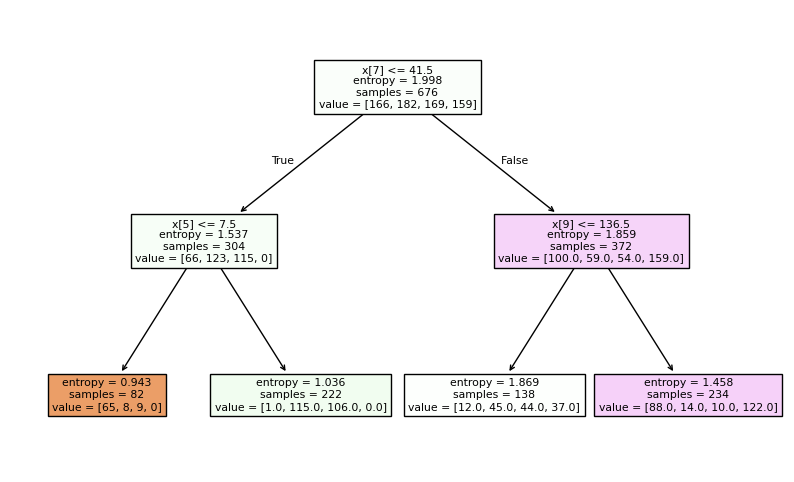

In [601]:
plt.figure(figsize=(10,6))
tree.plot_tree(model.fit(x_train,y_train),filled=True)
plt.show(True)

Veja a implementação original e estude os parâmetros do modelo: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

## Regressão

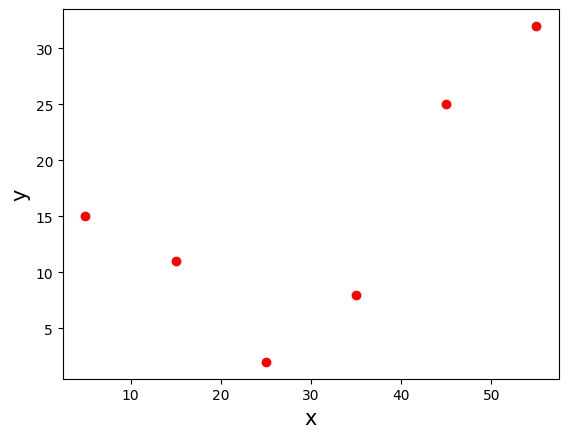

In [602]:
import numpy as np
from sklearn.linear_model import LinearRegression

x = np.array([5, 15, 25, 35, 45, 55])
y = np.array([15, 11, 2, 8, 25, 32])
plt.plot(x,y, 'ro')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)

plt.show(True)

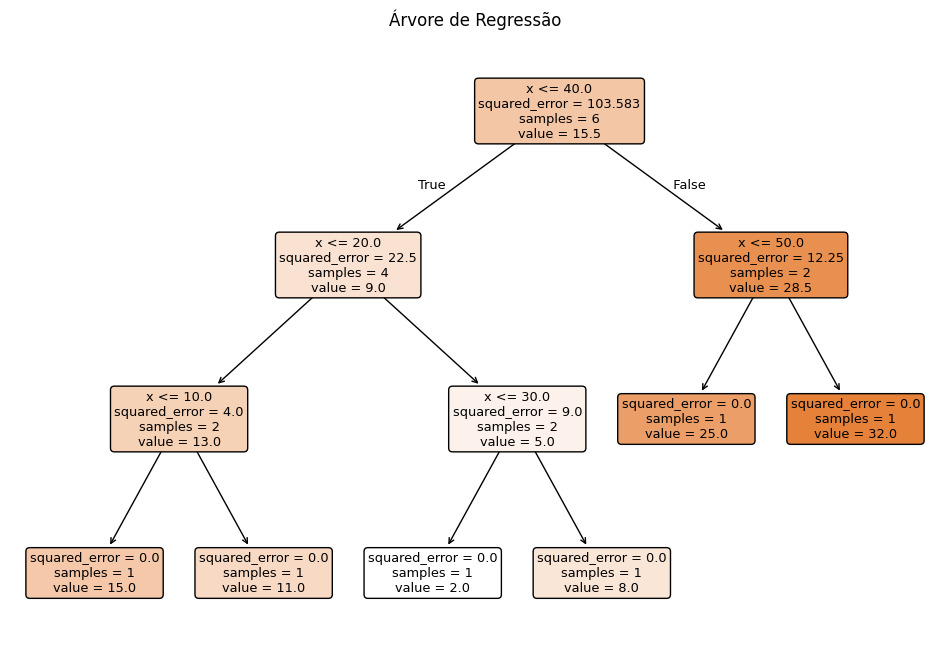

In [603]:
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# Criar o modelo de árvore de regressão
model_reg = DecisionTreeRegressor(random_state=42)

# Ajustar o modelo aos dados
model_reg.fit(x.reshape(-1, 1), y)

# Visualizar a árvore
plt.figure(figsize=(12, 8))
tree.plot_tree(model_reg, filled=True, feature_names=['x'], rounded=True)
plt.title("Árvore de Regressão");
plt.show()

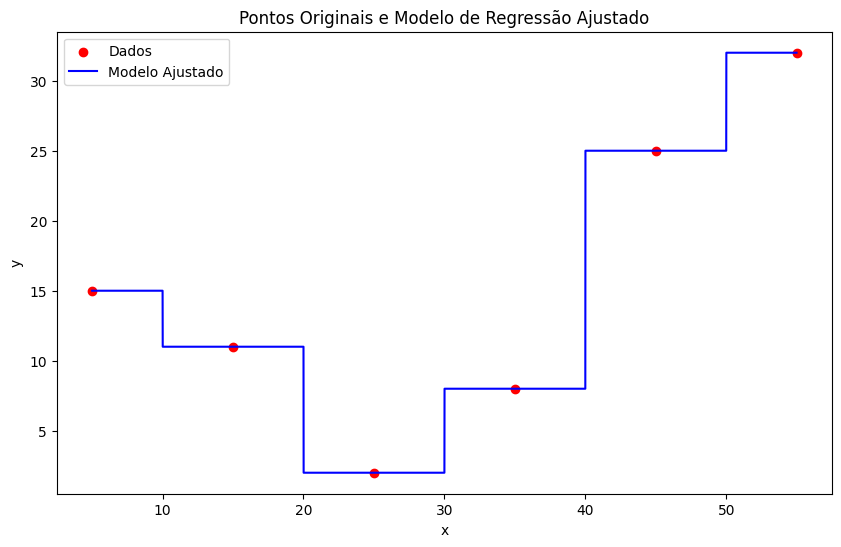

In [604]:
import numpy as np
import matplotlib.pyplot as plt

# Criar uma gama de valores x para a previsão
x_range = np.arange(x.min(), x.max(), 0.01).reshape(-1, 1)

# Fazer previsões com o modelo de regressão
y_pred_reg = model_reg.predict(x_range)

# Plotar os pontos originais
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', label='Dados')

# Plotar o modelo ajustado
plt.plot(x_range, y_pred_reg, color='blue', linestyle='-', label='Modelo Ajustado')

plt.title('Pontos Originais e Modelo de Regressão Ajustado')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## Exercícios para entregar

### Exericio 01


1 - Considere os dados abaixo. Ajuste um modelo de regressão usando: regressão polinomial, k-vizinhos e árvore de decisão.

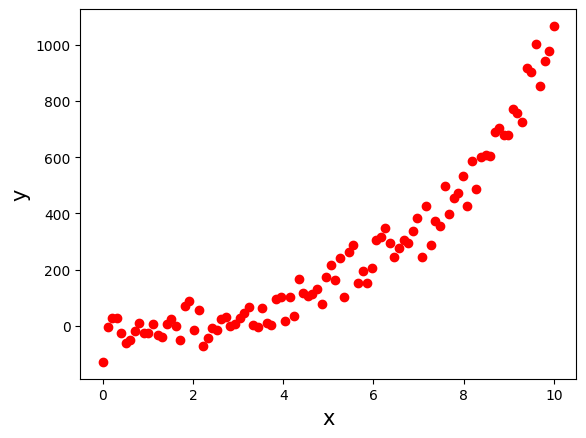

In [605]:
import numpy as np
from sklearn.linear_model import LinearRegression

N = 100
X = np.linspace(0,10,N)
y = X**3 + np.random.normal(0,50, N)
plt.plot(X,y, 'ro')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)

plt.show(True)

#### Modelo de Arvore de Decisao 

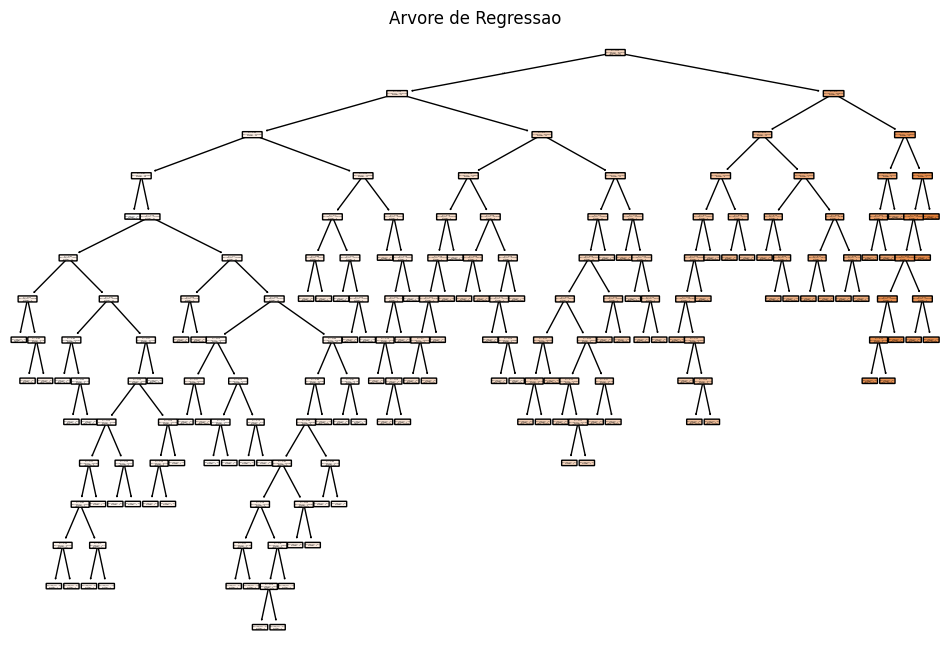

In [606]:
#Aplicando o metodo de regressao

#Criando o modelos de arvore de regressao - sem o uso de heuristicas
modelo_decTree = DecisionTreeRegressor(random_state=42)

#AJustando o modelos aos dados
modelo_decTree.fit(X.reshape(-1,1), y)

#visualizando a arvore obtida
plt.figure(figsize=(12,8))
tree.plot_tree(modelo_decTree, filled=True, feature_names=['x'], rounded=True)
plt.title("Arvore de Regressao")
plt.show()

#### Modelo De Regressao, grau 3, Ajustado.

In [607]:
from sklearn.preprocessing import PolynomialFeatures

In [608]:
#polinomio de grau 3
transf3 = PolynomialFeatures(degree=3, include_bias=False)
X = X.reshape((-1,1))
transf3.fit(X)

#passando os dados para grau 3
X_g3 = transf3.transform(X)

In [609]:
modelo_regressao = LinearRegression().fit(X_g3, y)
y_pred_g3 = modelo_regressao.predict(X_g3)

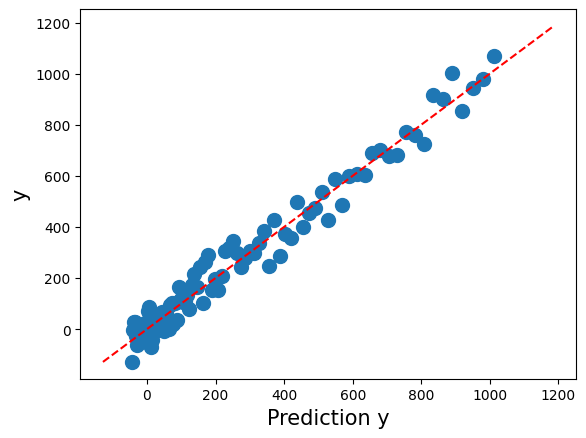

In [610]:


#visualização dos graficos linear e cubico
fig = plt.figure()
l = plt.plot(y_pred_g3, y, 'o', label="dados")
plt.setp(l, markersize=10)
plt.setp(l, markerfacecolor='C0')

plt.ylabel("y", fontsize=15)
plt.xlabel("Prediction y", fontsize=15)

# mostra a reta diagonal, que representa a predição perfeita
xl = np.arange(min(y), 1.2*max(y),(max(y)-min(y))/10)
yl = xl
plt.plot(xl, yl, 'r--', label="Modelo ajustado")

plt.show(True)

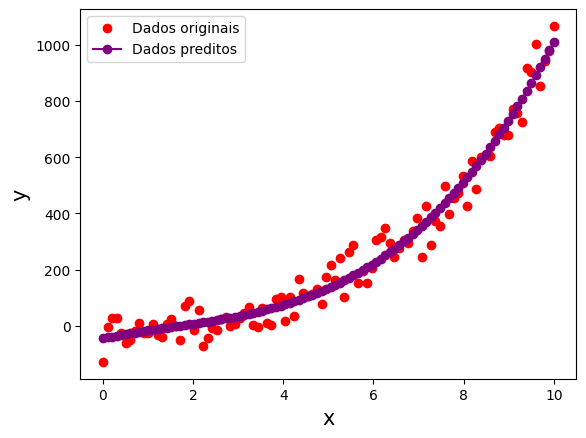

In [611]:
plt.plot(X,y, 'ro', label='Dados originais')
plt.plot(X,y_pred_g3, 'o-', color="purple",label = 'Dados preditos')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)
plt.legend()
plt.show(True)

#### Modelo KNN ajustado

In [612]:
from sklearn.neighbors import KNeighborsRegressor

In [613]:
modelo_vizinhos = KNeighborsRegressor(n_neighbors=5)
modelo_vizinhos.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [614]:
X_range = np.arange(X.min(), X.max(), 0.01).reshape(-1, 1)


In [615]:
Y_pred_viz = modelo_vizinhos.predict(X_range)

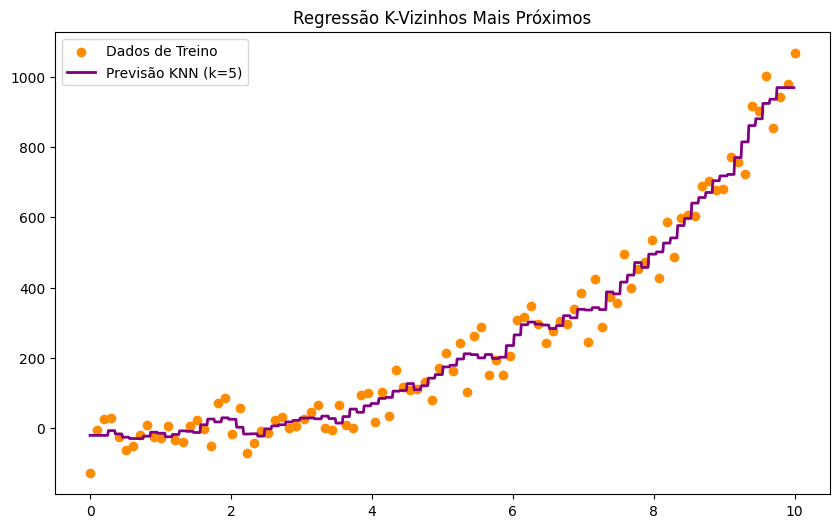

In [616]:
# 3. Visualizar
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='darkorange', label='Dados de Treino')
plt.plot(X_range, Y_pred_viz, color='purple', label='Previsão KNN (k=5)', linewidth=2)
plt.axis('tight')
plt.legend()
plt.title("Regressão K-Vizinhos Mais Próximos")
plt.show()

### Exercicio 02

Faça a classificação da base vertebralcolumn-3C.

In [617]:
data_col = pd.read_csv('./data/vertebralcolumn-3C.csv', header=(0))

#removendo nan
data_col = data_col.dropna(axis='rows')

# armazena o nome das classes
classes = np.array(pd.unique(data_col[data_col.columns[-1]]), dtype=str)  #name of the clases
features_names = data_col.columns

print("Número de linhas e colunas na matriz de atributos:", data_col.shape)
attributes = list(data_col.columns[0:-2])
#visualizando 
data_col.head(5)

Número de linhas e colunas na matriz de atributos: (310, 7)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Hernia
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Hernia
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia


In [618]:
#convertendo para NUMPY
data_col = data_col.to_numpy()
nlin, ncol = data_col.shape
y_col = data_col[:, -1]
X_col = data_col[:, 0:ncol-1]

In [619]:
#Definindo os conjuntos de treinamento e teste
p  = 0.3
x_col_train, x_col_test, y_col_train, y_col_test = train_test_split(X_col, y_col, test_size=p, random_state=42)

[Metrica Gini e Entropia](https://www.geeksforgeeks.org/machine-learning/gini-impurity-and-entropy-in-decision-tree-ml/) indicam o grau de impuresa e desordem do conjunto, juntas indicam o quão divísel são os dados

**Gini** Verifica a frequência com que uma amostra selecionada **aleatoriamente seria rotulada incorretamente** se fosse atribuída com base na probabilidade da classe. É computacionalmente simples e usada em classificadores baseados em árvores.

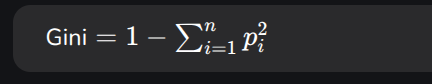

**Entropia** indica a incerteza na distribuição de classes de um nó tem origem na teoria da informação. Uma entropia mais alta indica maior desordem entre os rótulos de classe.

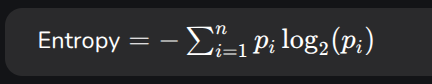


#### Usando a métrica de gini

In [620]:
#craindo o modelo com a metrica de gini e profundidade = 2
modelo_gini = tree.DecisionTreeClassifier(criterion='gini', random_state=101, max_depth=2)
# Ajusta o modelo usando os dados de treinamento
modelo_gini.fit(x_col_train,y_col_train)
# realizar a predição
y_pred_col = modelo_gini.predict(x_col_test)

In [621]:
#avaliando o desempenho
score_col = accuracy_score(y_pred_col, y_col_test)
print("Acurácia: ", score_col)

Acurácia:  0.8064516129032258


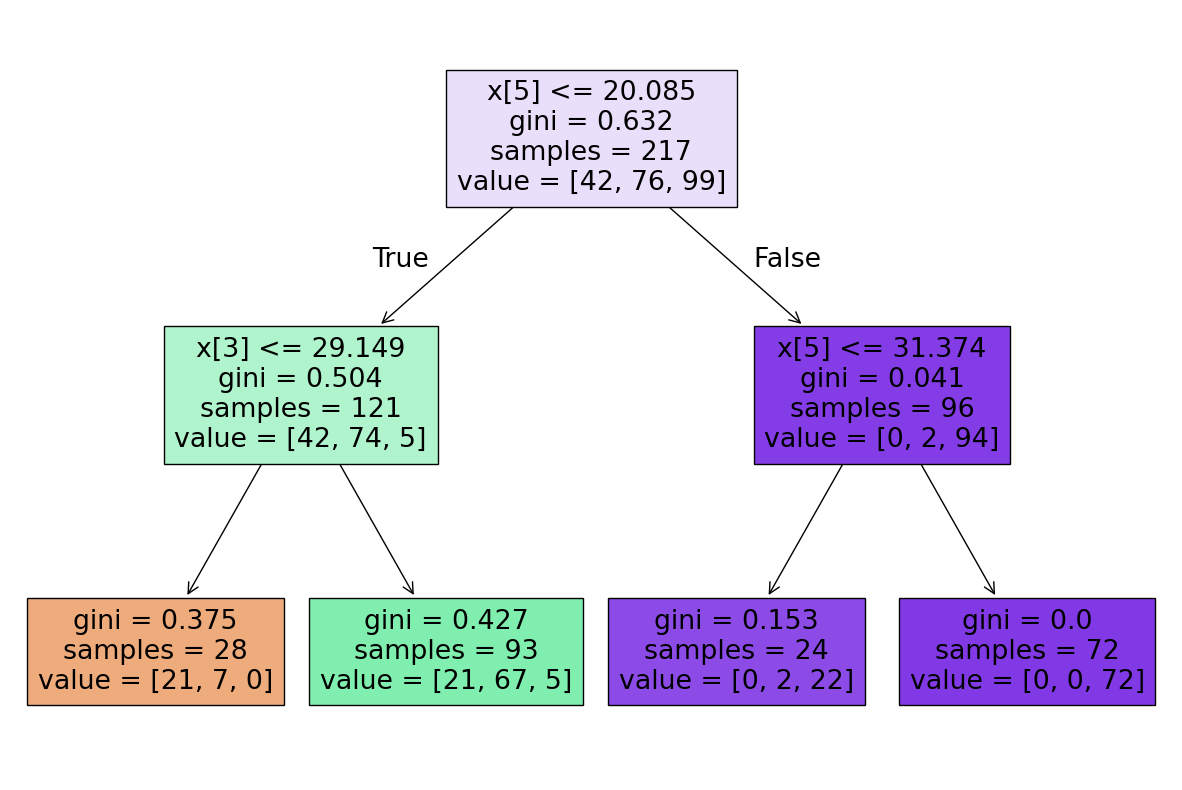

In [622]:
#visualizando a arvore
plt.figure(figsize=(15,10))
tree.plot_tree(modelo_gini.fit(x_col_train,y_col_train),filled=True)
plt.show(True)

#### Usando a métrica de Entropia

In [623]:
#craindo o modelo com a metrica de gini e profundidade = 2
modelo_H = tree.DecisionTreeClassifier(criterion='entropy', random_state=101, max_depth=2)
# Ajusta o modelo usando os dados de treinamento
modelo_H.fit(x_col_train,y_col_train)
# realizar a predição
y_pred_colH = modelo_H.predict(x_col_test)

In [624]:
#avaliando o desempenho
score_colH = accuracy_score(y_pred_colH, y_col_test)
print("Acurácia: ", score_colH)

Acurácia:  0.8172043010752689


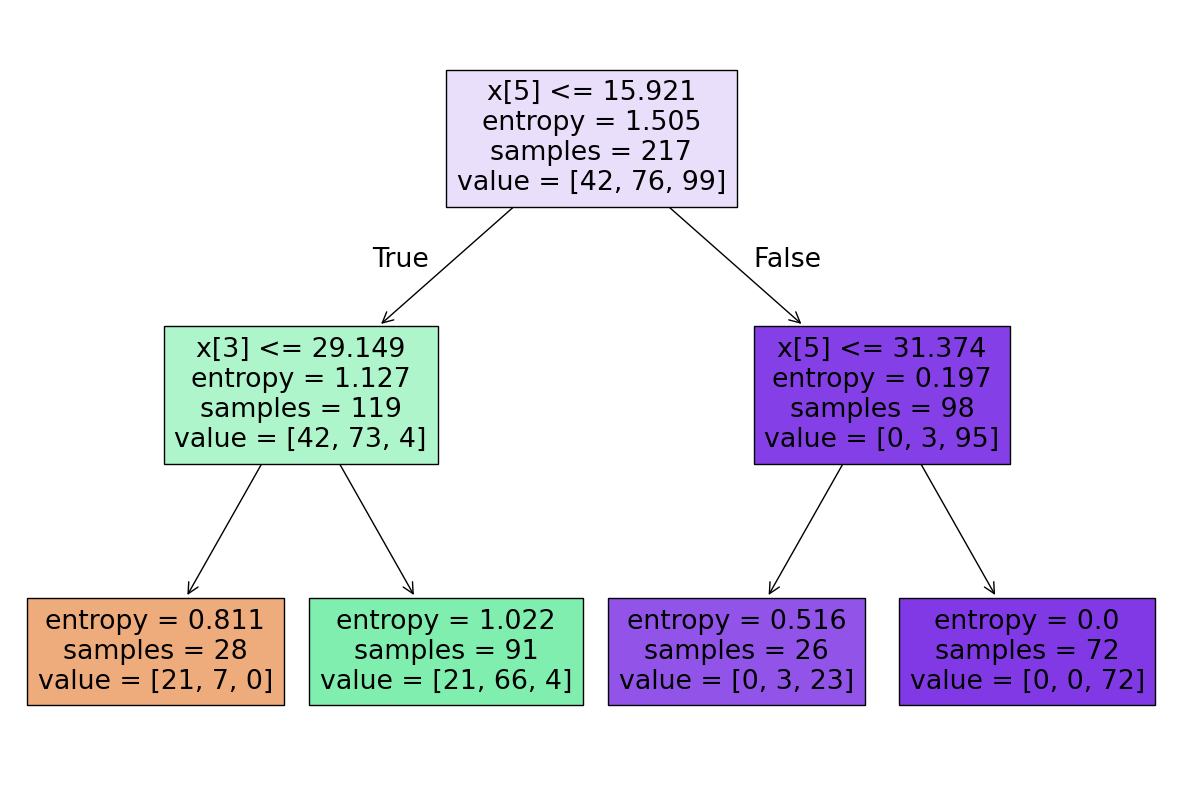

In [625]:
#visualizando a arvore
plt.figure(figsize=(15,10))
tree.plot_tree(modelo_H.fit(x_col_train,y_col_train),filled=True)
plt.show(True)

### Exercicio 3

Ajuste um modelo de regressão aos dados de concreto para predizer a variável
concrete_compressive_strength.

In [626]:
data_concrete = pd.read_csv("./data/concrete_data.csv")

#removendo nan
data_concrete = data_concrete.dropna(axis='rows')

# armazena o nome das classes
classes = np.array(pd.unique(data_concrete[data_concrete.columns[-1]]), dtype=str)  #name of the clases
features_names = data_concrete.columns

print("Número de linhas e colunas na matriz de atributos:", data_concrete.shape)
attributes = list(data_concrete.columns[0:-2])
#visualizando 
data_concrete.head(5)

Número de linhas e colunas na matriz de atributos: (1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [627]:
#convertendo para NUMPY
data_concrete = data_concrete.to_numpy()
nlin, ncol = data_concrete.shape
#divindo os dados entre Exemplos  e saida
y_concrete = data_concrete[:, -1]
X_concrete = data_concrete[:, 0:ncol-1]

In [628]:
def plot3(x1,y1, x2, x3):
    # Criando a figura com 3 subplots (1 linha, 3 colunas)
    plt.figure(figsize=(15, 4))

    # Gráfico 1 - Linear()
    plt.subplot(1, 3, 1)
    l = plt.plot(x1, y1, 'bo')
    plt.setp(l, markersize=10)
    plt.setp(l, markerfacecolor='C0')
    plt.title("Linear")
    plt.xlabel("prediction y")
    plt.ylabel("y")

    # mostra a reta diagonal, que representa a predição perfeita
    xl = np.arange(min(y1), 1.2*max(y1),(max(y1)-min(y1))/10)
    yl = xl
    plt.plot(xl, yl, 'r--')


    # Gráfico 2
    plt.subplot(1, 3, 2)
    l2 = plt.plot(x2, y1, 'bo')
    plt.setp(l2, markersize=10)
    plt.setp(l2, markerfacecolor='C0')
    plt.title("Polinomial(G=3)")
    plt.xlabel("prediction y")
    plt.ylabel("y")

    # mostra a reta diagonal, que representa a predição perfeita
    xl2 = np.arange(min(y1), 1.2*max(y1),(max(y1)-min(y1))/10)
    yl2 = xl2
    plt.plot(xl2, yl2, 'r--')

    # Gráfico 3
    plt.subplot(1, 3, 3)
    l3 = plt.plot(x3, y1, 'bo')
    plt.setp(l3, markersize=10)
    plt.setp(l3, markerfacecolor='C0')
    plt.title("KNN(k=5)")
    plt.xlabel("prediction y")
    plt.ylabel("y")

    # mostra a reta diagonal, que representa a predição perfeita
    xl3 = np.arange(min(y1), 1.2*max(y1),(max(y1)-min(y1))/10)
    yl3 = xl3
    plt.plot(xl3, yl3, 'r--')

    # Ajusta layout
    plt.tight_layout()

    # Exibe os gráficos
    plt.show()

In [629]:
from sklearn.metrics import mean_squared_error, r2_score


In [630]:
def modelo_regresao(X_train, X_test, Y_train, Y_test):
    #Linear
    m_lin = LinearRegression().fit(X_train, Y_train)
    y_pred_lin = m_lin.predict(X_test)

    #polinomial de grau 3
    transf3 = PolynomialFeatures(degree=3, include_bias=False)
    X_train_r = X_train
    X_test_r = X_test
    X_train3 = transf3.fit_transform(X_train_r)
    X_test3 = transf3.transform(X_test_r)
    m3 = LinearRegression().fit(X_train3, Y_train)
    Y_pred3 = m3.predict(X_test3)


    #knn
    modelo_vizinhos = KNeighborsRegressor(n_neighbors=5)
    modelo_vizinhos.fit(X_train, Y_train)
    Y_pred_viz = modelo_vizinhos.predict(X_test)

    #desempenho
    # Linear
    scr_lin = mean_squared_error(Y_test, y_pred_lin)
    r2_lin = r2_score(Y_test, y_pred_lin)

    # Polinomial grau 3
    scr_3 = mean_squared_error(Y_test, Y_pred3)
    r2_3 = r2_score(Y_test, Y_pred3)

    # KNN
    scr_k = mean_squared_error(Y_test, Y_pred_viz)
    r2_k = r2_score(Y_test, Y_pred_viz)
    
    #Printando
    print("Modelo Linear: MSE =", scr_lin, "| R2 =", r2_lin)
    print("Modelo Polinomial(Grau 3): MSE =", scr_3, "| R2 =", r2_3)
    print("Modelo KNN(n=5): MSE =", scr_k, "| R2 =", r2_k)

    #graficos
    plot3(y_pred_lin, Y_test, Y_pred3,  Y_pred_viz)
    

In [631]:
#subdivindo os conjuntos entre treinamento e teste
p = 0.3
x_coc_train, x_coc_test, y_coc_train, y_coc_test = train_test_split(X_concrete, y_concrete, test_size=p, random_state=42)

Modelo Linear: MSE = 109.75080797014404 | R2 = 0.5943782479239206
Modelo Polinomial(Grau 3): MSE = 37.12360588270275 | R2 = 0.8627969821814883
Modelo KNN(n=5): MSE = 87.40241851132686 | R2 = 0.6769743859936284


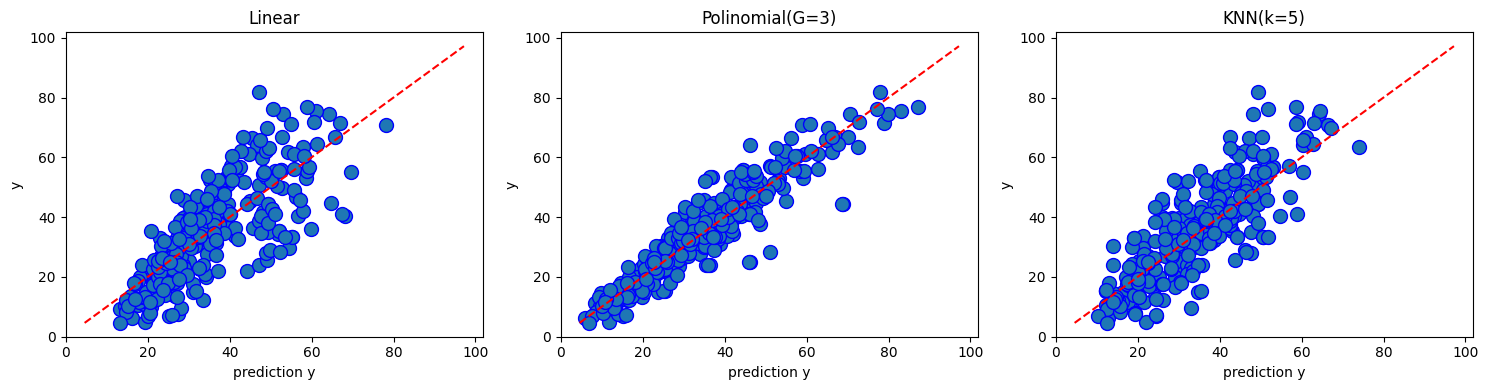

In [632]:
modelo_regresao(x_coc_train, x_coc_test, y_coc_train, y_coc_test)

### Exercício 4

Escolha uma base de dados e compare a influencia da medida de impureza na classificação e regressão (Gini, Entropia, etc).

In [633]:
data = pd.read_csv('./data/vertebralcolumn-2C.csv', header=(0))

#removendo nan
data = data.dropna(axis='rows')

# armazena o nome das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)  #name of the clases
features_names = data.columns

print("Número de linhas e colunas na matriz de atributos:", data.shape)
attributes = list(data.columns[0:-2])
#visualizando 
data.head(5)

Número de linhas e colunas na matriz de atributos: (310, 7)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal


In [634]:
#Mudando o valor da classe
data['class'] = data['class'].replace({'Abnormal': '0', 'Normal': '1'})


In [635]:
data.head(5)

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,0
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,0
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,0
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,0
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,0


In [636]:
#convertendo para NUMPY
data = data.to_numpy()
nlin, ncol = data.shape
#divindo os dados entre Exemplos  e saida
y = data[:, -1]
X = data[:, 0:ncol-1]

In [637]:
#subdivindo os conjuntos entre treinamento e teste
p = 0.3
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=p, random_state=42)

#### Classificação

In [638]:
# Cria o modelo usando o criterio Gini
modelG = tree.DecisionTreeClassifier(criterion = 'gini', random_state = 101, max_depth = 2)
# Ajusta o modelGo usando os dados de treinamento
modelG.fit(x_train,y_train)
# realizar a predição
y_predG = modelG.predict(x_test)
scoreG = accuracy_score(y_predG, y_test)
print('Accuracy:', scoreG)

Accuracy: 0.8064516129032258


In [639]:
modelH = tree.DecisionTreeClassifier(criterion = 'entropy',random_state = 101, max_depth = 2)
modelH.fit(x_train,y_train)
y_predH = modelH.predict(x_test)

scoreH = accuracy_score(y_predH, y_test)
print('Accuracy:', scoreH)

Accuracy: 0.8064516129032258


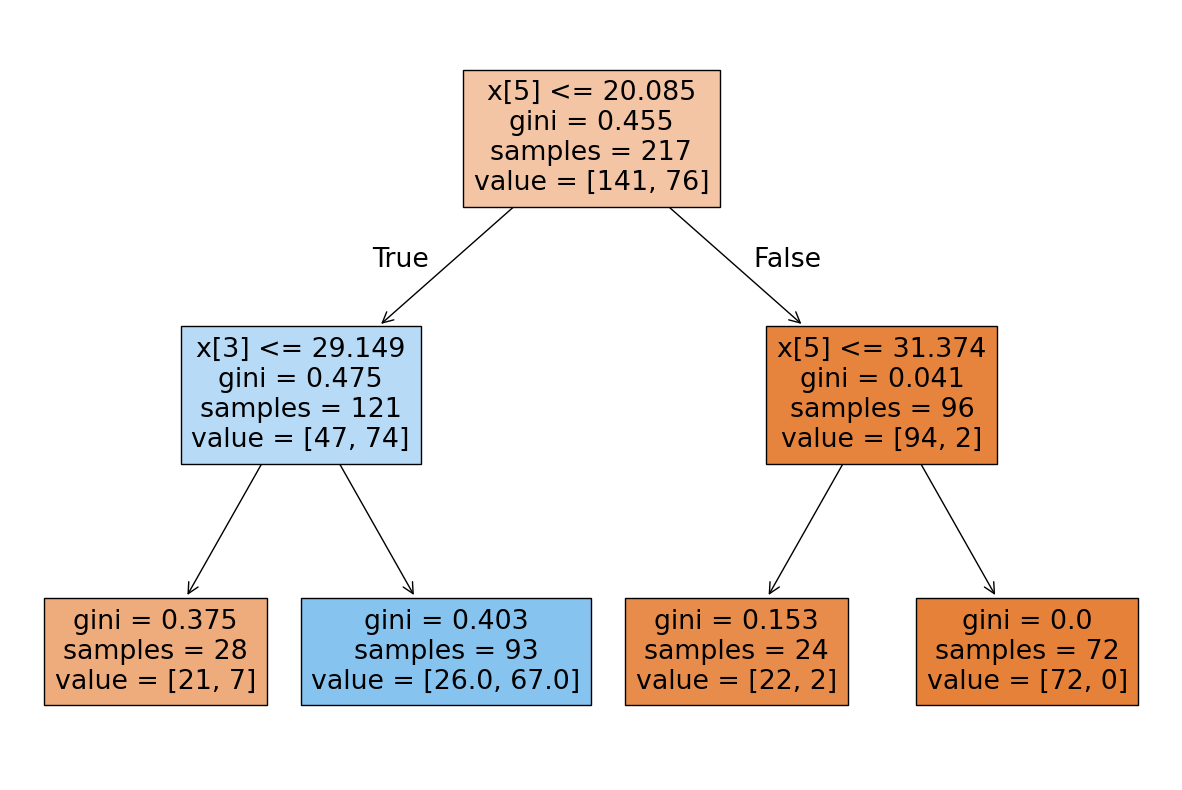

In [640]:

plt.figure(figsize=(15, 10))

# Gráfico 1 - Gini
tree.plot_tree(modelG.fit(x_train,y_train),filled=True)
plt.show(True)



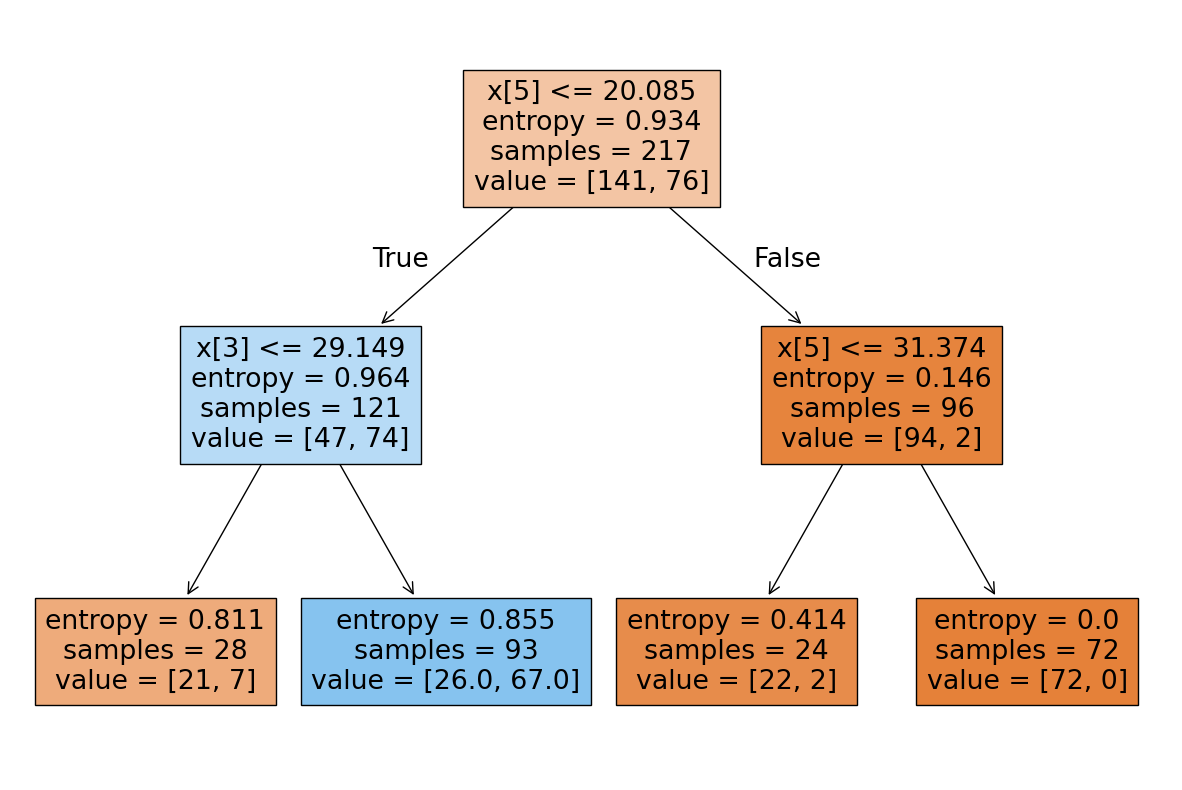

In [641]:
plt.figure(figsize=(15, 10))


# Gráfico 2 - entropia
tree.plot_tree(modelH.fit(x_train,y_train),filled=True)
plt.show(True)

### Exercicio 5

Considere um conjunto de dados com n observações (Vehicle).
* Gere uma nova amostra de treinamento selecionando n observações de forma aleatória com reposição a
partir do conjunto de dados original. Esse procedimento é conhecido como reamostragem bootstrap.
*  Utilize essa nova amostra para treinar uma árvore de decisão.
* Repita esse processo B vezes, gerando B árvores diferentes.
* Para classificar uma nova observação x, utilize todas as árvores geradas e registre a classe prevista por
cada uma delas.
* A classificação final de x deve ser obtida pela moda das previsões das B árvores, isto é, pela classe mais
frequentemente prevista.
* Faça um gráfico de B versus a acurácia. Esse processo melhora a classificação?

Obtenha um gráfico como esse:
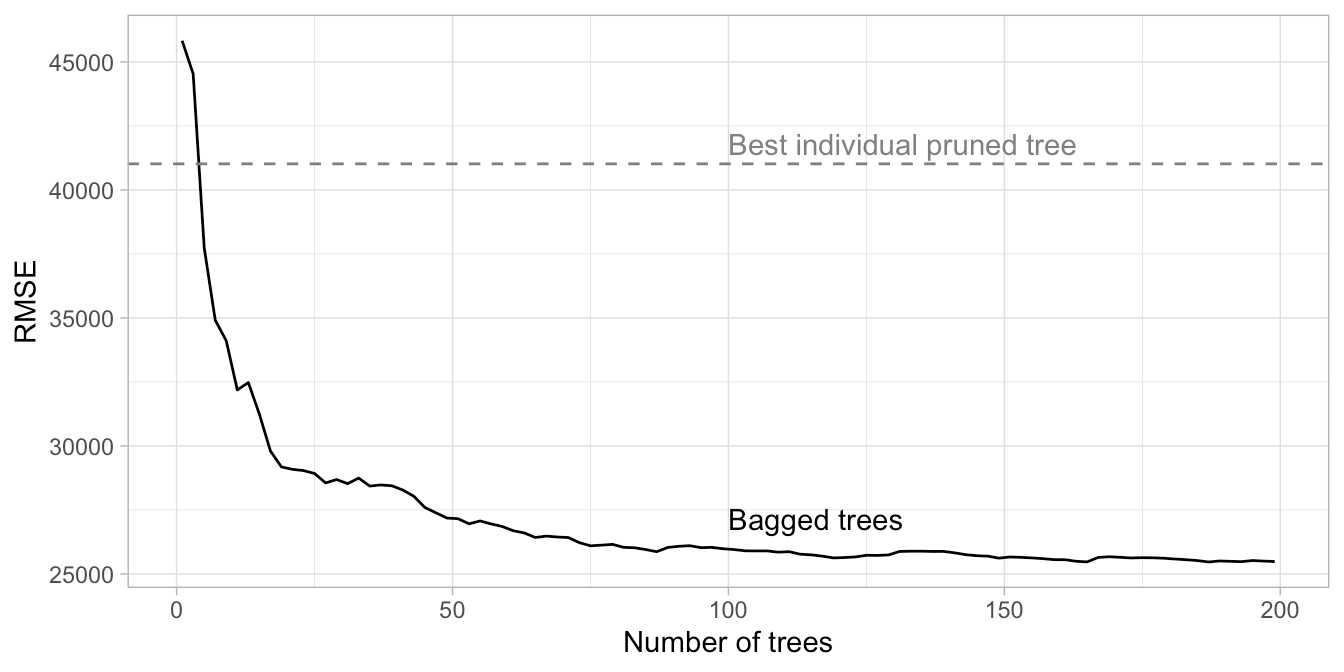